In [170]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import time
from sklearn.neighbors import KNeighborsClassifier


# 1. Load  “bank-additional-full.csv” dataset and create a support vector machine model with a linear kernel and default C value for predicting target variable (subscribed a term deposit or not). Select appropriate data splitting approach and performance metrics.  Report the model performance.

In [91]:
df = pd.read_csv("https://raw.githubusercontent.com/nay-deakin/sit720-data/refs/heads/main/bank-additional/bank-additional-full.csv", delimiter=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### See if there are null rows
##### Looks like there are none so we don't have to worry about nulls


In [93]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### Lets look at text column to see if we need to do one hot encoding
### Also check which text column have how many unique values

In [94]:
for col in df.select_dtypes(include="object"):
    print (col, df[col].nunique(),list(df[col].unique()))

job 12 ['housemaid', 'services', 'admin.', 'blue-collar', 'technician', 'retired', 'management', 'unemployed', 'self-employed', 'unknown', 'entrepreneur', 'student']
marital 4 ['married', 'single', 'divorced', 'unknown']
education 8 ['basic.4y', 'high.school', 'basic.6y', 'basic.9y', 'professional.course', 'unknown', 'university.degree', 'illiterate']
default 3 ['no', 'unknown', 'yes']
housing 3 ['no', 'yes', 'unknown']
loan 3 ['no', 'yes', 'unknown']
contact 2 ['telephone', 'cellular']
month 10 ['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr', 'sep']
day_of_week 5 ['mon', 'tue', 'wed', 'thu', 'fri']
poutcome 3 ['nonexistent', 'failure', 'success']
y 2 ['no', 'yes']


### Treat education as ordinal column
### Treat the rest of text columns as nominal and use One Hot Encoding
### The numeric columns as is

In [95]:
X = df.drop(columns='y')
y = df['y'].map({'yes':1, 'no': 0})

### Check the class imbalance

In [96]:
df.groupby('y')['y'].count() / df['y'].count()

y
no     0.887346
yes    0.112654
Name: y, dtype: float64

In [97]:
numeric_cols = list(X.select_dtypes(include=['float64', 'int64']).columns)
ordinal_cols = ['education']
education_order = [
    ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'professional.course', 'university.degree', 'unknown']
]
nominal_cols = [col for col in list(X.select_dtypes(include="object")) if col not in ordinal_cols]


##### Use sci-kit learn pipeline

In [98]:
nominal_pipeline = Pipeline([
    ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=education_order, handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('nominal', nominal_pipeline, nominal_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('numeric', StandardScaler(),   numeric_cols)   # numeric cols pass through unchanged
])

In [99]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(kernel='linear', random_state=1)),
])

In [100]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=1, stratify=y
# )

# StratifiedShuffleSplit gave a slightly more accurate result

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(sss.split(X, y))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

### Training/Testing Accuracy: 

In [120]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, model.decision_function(X_test))


print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")
print (f"Model C: {model.named_steps['classifier'].C}")

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.67      0.31      0.43       928

    accuracy                           0.91      8238
   macro avg       0.80      0.65      0.69      8238
weighted avg       0.89      0.91      0.89      8238

[[7169  141]
 [ 636  292]]

Accuracy  : 0.9057
ROC-AUC   : 0.9400
Model C: 1.0


##### Above is the result of training a support vector machine model (SVM) with a linear kernel and default C value (C=1.0).  The goal is to predict whether a bank client would subscribe to a term deposit.  The dataset was split using the sklearn StartifiedShuffleSplit with 80/20 train/test.  This is to hopefully account for the class imbalance 89/11 N/Y.  Overall the model peformance is reasonabily ok with a 91% accuracy on the test set and the ROC-AUC of 0.94 which suggest it did a solid job distinquishing between subscribers and non-subscribers.

##### The model is much stronger predicting the majority class (people who do not subscribe), achieving a precision of 0.92, recall of 0.98 and F1 of 0.95.  It is weaker at predicting subscribers with a precision of 0.67, recall of 0.31 and F1 of 0.43.  This means the model only catches 1 in 3 subscribers.

##### In conclusion the model is conservative, it rarely raises false positives but that means it also misses a good portion of genuine subscribers.

#

# 2. Continue from question 1, try different C values for the model, report the model performance on the test set and the optimal C. Is the optimal C different from the default C value ? How does the margin change when C changes from the default valune to the optimal one? Explain with plots.

In [164]:
param_grid = {'classifier__C': [ 0.01, 0.1, 1, 10]}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,                     # 5-fold stratified cross-validation
    scoring='f1',             # use 'f1' for minority class, or 'roc_auc'
    n_jobs=-1,                # use all CPU cores
    verbose=1
)



In [165]:
grid_search.fit(X_train, y_train)
y_pred = grid_search.predict(X_test)


acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, grid_search.decision_function(X_test))

print(f"Best C      : {grid_search.best_params_['classifier__C']}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")


print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits


Best C      : 1
Best CV F1  : 0.4107
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7310
           1       0.67      0.31      0.43       928

    accuracy                           0.91      8238
   macro avg       0.80      0.65      0.69      8238
weighted avg       0.89      0.91      0.89      8238

[[7169  141]
 [ 636  292]]

Accuracy  : 0.9057
ROC-AUC   : 0.9400


In [166]:
print (grid_search.param_grid)

{'classifier__C': [0.01, 0.1, 1, 10]}


##### Function copied from Week7 workshop example

In [129]:
from matplotlib.colors import ListedColormap

# We define a colormap with three colors, for three labels our data
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

def plot_estimator(estimator, X, y):
    '''
    This function takes a model (estimator),
    '''
    print()
    estimator.fit(X, y)
    # Determine the maximum and minimum mesh as a boundary
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    # Generating the points on the mesh
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100))
    # Make predictions on the grid points
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])

    # for color
    Z = Z.reshape(xx.shape)
    plt.figure()
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Original training sample
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
    plt.axis('tight')
    plt.axis('off')
    plt.tight_layout()

In [132]:
X

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6


##### For the plot to work we need PCA to reduce X to 2d 


##### Custome function fit_with_C created to not repeat the code.  This function refits the model with PCA 2d so we can draw a chart.  It resamples as well to not overaload the chart.

In [153]:
from sklearn.decomposition import PCA
from sklearn.utils import resample

def fit_with_C (X, y, C, sample_size=500):
    X_preproc = preprocessor.fit_transform(X, y)
    X_2d = PCA(n_components=2).fit_transform(X_preproc)

    X_vis, y_vis = resample(X_2d, y, n_samples=sample_size, random_state=42, stratify=y)

    
    svm_2d = svm.SVC(kernel='linear', C=C, random_state=1)
    svm_2d.fit(X_vis, y_vis)
    return svm_2d, X_vis, y_vis

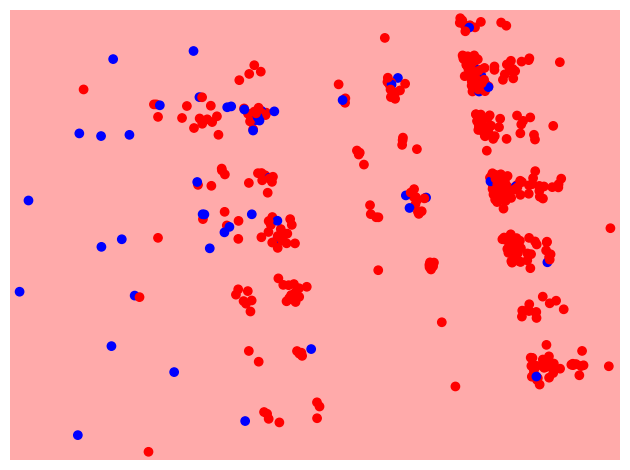

In [154]:
model_vis, X_vis, y_vis = fit_with_C(X, y, grid_search.best_params_['classifier__C'], 500)
plot_estimator(model_vis,X_vis,y_vis)

##### The above plot doesn't look right so got Claude to create a plot_margin function with the following prompt, "Sample python code to plot the margin"

In [157]:
def plot_margin(model, X, y):
    plt.figure(figsize=(7, 5))
    ax = plt.gca()

    # decision region background
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                        np.linspace(y_min, y_max, 300))

    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # shaded regions
    ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
                colors=['#AAAAFF', '#FFAAAA'], alpha=0.3)

    # decision boundary (Z=0) and margin lines (Z=±1)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
            colors=['blue', 'black', 'red'],
            linestyles=['--', '-', '--'],
            linewidths=[1.2, 2, 1.2])

    # scatter points
    ax.scatter(X[y==0, 0], X[y==0, 1], color='blue',
            edgecolors='white', s=50, zorder=3, label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='red',
            edgecolors='white', s=50, zorder=3, label='Class 1')

    # support vectors
    ax.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='black',
            linewidths=1.5, zorder=4, label='Support vectors')

    # annotate margin width
    margin = 2 / np.linalg.norm(model.coef_)
    ax.set_title(f'SVM linear kernel  |  C = {model.C}  |  Margin = {margin:.2f}  |  SVs = {len(model.support_vectors_)}')
    ax.legend(loc='upper left', fontsize=9)
    ax.axis('tight')
    
    plt.show()
    
    

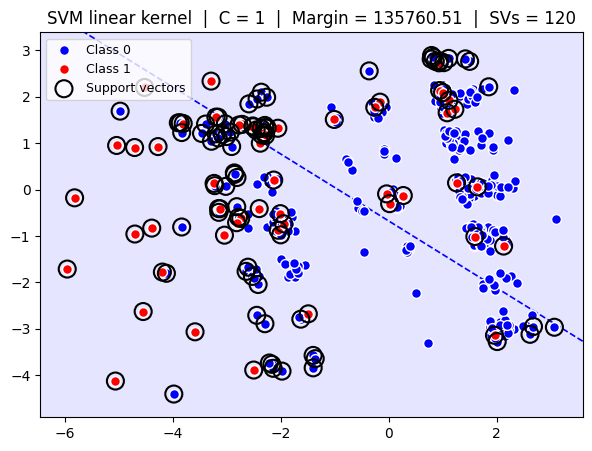

In [158]:
model_vis2, X_vis2, y_vis2 = fit_with_C(X, y, grid_search.best_params_['classifier__C'], 500)

plot_margin(model_vis2,X_vis2,y_vis2)

##### Best C is the same as the default which is 1

### Fitting with C=10 to see the diff

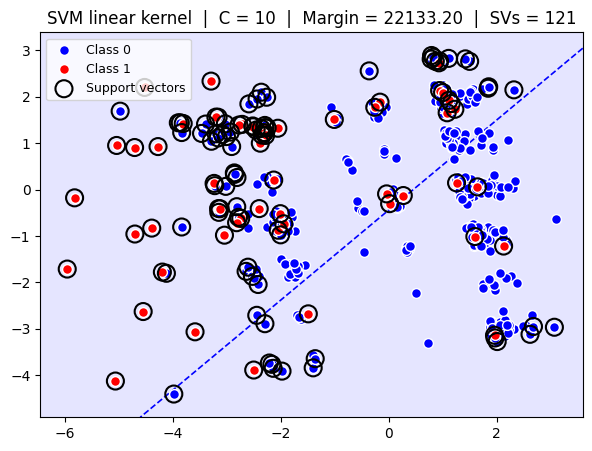

In [162]:
model_vis3, X_vis3, y_vis3 = fit_with_C(X, y, 10, 500)

plot_margin(model_vis3,X_vis3,y_vis3)

#

# 3. Continual from question 2, use the same training and test set, try other two kernel functions: RBF and ploy. Do hyperparameter tuning on C, gamma (RBF) and degree (poly). Find out the best hyperparameter setting.

### RBF model gridsearch first

In [174]:
model_rbf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(kernel='rbf', random_state=1, probability=True)),
])

##### This thing is slow using randomsearchCV to speed things up

In [181]:
param_grid_rbf = {
    'classifier__C': [  100, 1000, 10000],
    'classifier__gamma': ['scale', 'auto', 0.1, 1]
}

grid_search_rbf = RandomizedSearchCV(
    model_rbf,
    param_grid_rbf,
    cv=5,                     # 5-fold stratified cross-validation
    scoring='f1',             # use 'f1' for minority class, or 'roc_auc'
    n_jobs=-1,                # use all CPU cores
    verbose=1
)



In [182]:
grid_search_rbf.fit(X_train, y_train)
y_pred = grid_search_rbf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, grid_search_rbf.decision_function(X_test))

print(f"Best C      : {grid_search_rbf.best_params_['classifier__C']}")
print(f"Best CV F1  : {grid_search_rbf.best_score_:.4f}")
print(f"Best gamma      : {grid_search_rbf.best_params_['classifier__gamma']}")

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best C      : 100
Best CV F1  : 0.5107
Best gamma      : auto
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.63      0.45      0.53       928

    accuracy                           0.91      8238
   macro avg       0.78      0.71      0.74      8238
weighted avg       0.90      0.91      0.90      8238

[[7061  249]
 [ 509  419]]

Accuracy  : 0.9080
ROC-AUC   : 0.9217


### Poly best params

In [183]:
model_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(kernel='poly', random_state=1, probability=True)),
])

In [189]:
param_grid_poly = {
    'classifier__C': [ 10,100,100],
    'classifier__degree': [1,2, 3],
    'classifier__gamma': ['scale', 'auto']
}

grid_search_poly = RandomizedSearchCV(
    model_poly,
    param_grid_poly,
    cv=5,                     # 5-fold stratified cross-validation
    scoring='f1',             # use 'f1' for minority class, or 'roc_auc'
    n_jobs=-1,                # use all CPU cores
    verbose=1
)



In [190]:
grid_search_poly.fit(X_train, y_train)
y_pred = grid_search_poly.predict(X_test)


acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, grid_search_poly.decision_function(X_test))

print(f"Best C      : {grid_search_poly.best_params_['classifier__C']}")
print(f"Best CV F1  : {grid_search_poly.best_score_:.4f}")
print(f"Best gamma      : {grid_search_poly.best_params_['classifier__gamma']}")
print(f"Best degree      : {grid_search_poly.best_params_['classifier__degree']}")

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best C      : 100
Best CV F1  : 0.5058
Best gamma      : scale
Best degree      : 2
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7310
           1       0.68      0.42      0.52       928

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238

[[7126  184]
 [ 537  391]]

Accuracy  : 0.9125
ROC-AUC   : 0.9388


### Best Parameters
|Kernel|Hyper parameter|Best value|
|------|---------------|----------|
|Linear|C|1|
|RBF|C|100|
|RBF|gamma|auto|
|poly|C|100|
|poly|gamma|scale|
|poly|degree|2|

##### RBF kernel has better F1 score for the minority class compared to Linear kernel.  RBF minority class F1 score 0.53 vs Linear 0.43
##### Poly performs slightly worse than RBF with 0.52 F1 score for the minority class.


#

# 4. Given  the  best  hyperparameter  setting,  how  many  support vectors are there for the SVM model ? What are those support vectors indicate? 

In [195]:
print (f"linear Kernel # Support Vectors: {len(grid_search.best_estimator_.named_steps['classifier'].support_vectors_)}")
print (f"RBF Kernel # Support Vectors: {len(grid_search_rbf.best_estimator_.named_steps['classifier'].support_vectors_)}")
print (f"Poly Kernel # Support Vectors: {len(grid_search_poly.best_estimator_.named_steps['classifier'].support_vectors_)}")

linear Kernel # Support Vectors: 6661
RBF Kernel # Support Vectors: 6498
Poly Kernel # Support Vectors: 6352


- Support vecotrs are the training data points that lie closest to the decision boundary or within the margin.
- They are the only points that directly influence where the boundary is drawn.
- If you remove a support vector the boundary will shift, as opposed to removing any other data point and the boundary remains the same.
- Higher C will result in narrower margin and more support vectors.

#

# 5. Continue from question 3, given that the data set is imbalanced, use  one  appropriate  method  on  SVM  to  deal  with  class imbalance issue, justify your method. 
 


In [203]:
model_rbf1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', svm.SVC(
        kernel='rbf', 
        random_state=1, 
        probability=True,
        C = grid_search_rbf.best_params_['classifier__C'],
        gamma = grid_search_rbf.best_params_['classifier__gamma'],
        class_weight='balanced',
    )),
])

In [205]:
model_rbf1.fit(X_train, y_train)
y_pred = model_rbf1.predict(X_test)


acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, model_rbf1.decision_function(X_test))

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy  : {acc:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

              precision    recall  f1-score   support

           0       0.98      0.87      0.92      7310
           1       0.45      0.83      0.59       928

    accuracy                           0.87      8238
   macro avg       0.71      0.85      0.75      8238
weighted avg       0.92      0.87      0.88      8238

[[6377  933]
 [ 157  771]]

Accuracy  : 0.8677
ROC-AUC   : 0.9280


- The dataset has class inbalance 89%/11%, yes/no.
- With the hyperparameter class_weight='balanced', it addresses this by automatically increasing the miscalculation penalty for the minority class (subscribers) proportional to how underrepresented it is.
- The "yes" class gets roughly 8x times more penalty than the "no" when misclassified, forcing the model to focus on subscribers class.
- Minority class recall should go up.
- Overall accuracy should drop slighly.